In [37]:
import numpy as np
import pandas as pd

from IPython.core.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio


import seaborn as sns
from importlib import reload
import matplotlib.pyplot as plt
import matplotlib
import warnings


In [38]:
df = pd.read_csv('train.csv')

In [39]:
df.head()

,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],failure
0,M18918,302.0,310.9,1456,47.2,54,0
1,M16081,297.0,308.3,1399,46.4,132,0
2,M21755,301.0,311.6,1357,45.6,137,0
3,L57043,298.9,309.8,1411,56.3,84,0
4,L55891,297.1,308.5,1733,28.7,50,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               8000 non-null   object 
 1   Air temperature [K]      8000 non-null   float64
 2   Process temperature [K]  8000 non-null   float64
 3   Rotational speed [rpm]   8000 non-null   int64  
 4   Torque [Nm]              8000 non-null   float64
 5   Tool wear [min]          8000 non-null   int64  
 6   failure                  8000 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 437.6+ KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product ID,8000,8000,L48224,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],8000.0,NaN,NaN,NaN,300.00545,1.996844,295.3,298.3,300.1,301.5,304.5
Process temperature [K],8000.0,NaN,NaN,NaN,310.006062,1.479432,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],8000.0,NaN,NaN,NaN,1539.356875,180.982943,1168.0,1422.0,1503.0,1613.0,2886.0
Torque [Nm],8000.0,NaN,NaN,NaN,40.003363,10.019546,3.8,33.2,40.1,46.8,76.6
Tool wear [min],8000.0,NaN,NaN,NaN,107.685,63.612002,0.0,53.0,107.0,163.0,253.0
failure,8000.0,NaN,NaN,NaN,0.033875,0.180919,0.0,0.0,0.0,0.0,1.0


In [41]:
df.replace("?",np.nan,inplace=True)

In [42]:
for column in df.columns:
    try:
        df[column]=df[column].astype(float)
    except:
        pass

In [43]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],8000.0,300.005450,1.996844,295.3,298.3,300.1,301.5,304.5
Process temperature [K],8000.0,310.006062,1.479432,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],8000.0,1539.356875,180.982943,1168.0,1422.0,1503.0,1613.0,2886.0
Torque [Nm],8000.0,40.003363,10.019546,3.8,33.2,40.1,46.8,76.6
Tool wear [min],8000.0,107.685000,63.612002,0.0,53.0,107.0,163.0,253.0
failure,8000.0,0.033875,0.180919,0.0,0.0,0.0,0.0,1.0


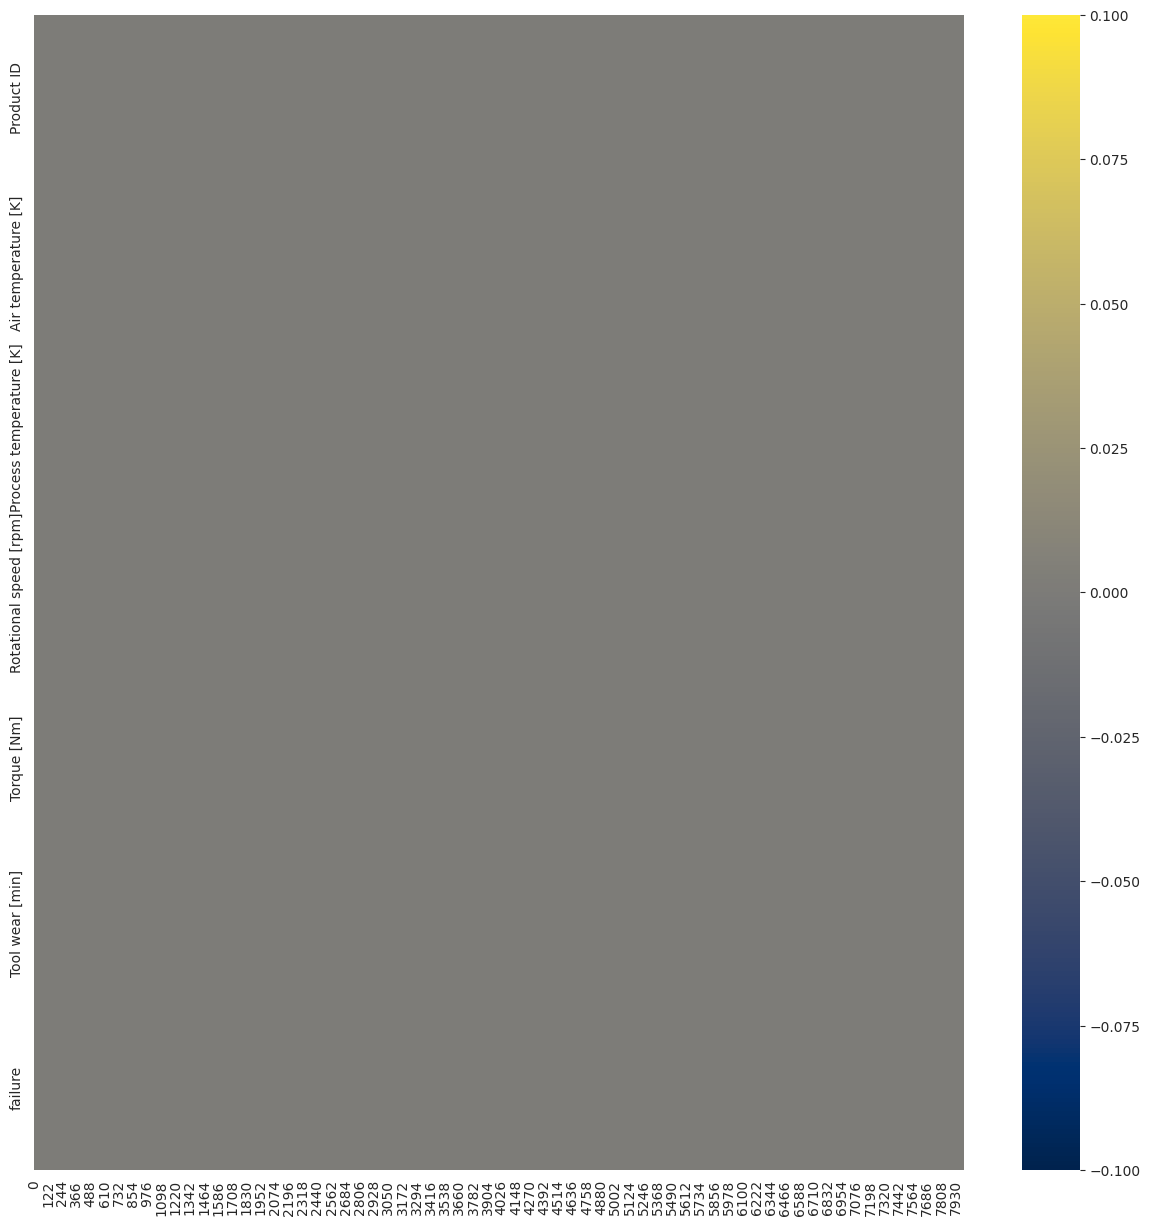

In [44]:
plt.figure(figsize=(15,15))
plot_kws={"s": 1}
sns.heatmap(df.isna().transpose(),
            cmap='cividis',
            linewidths=0.0,
           ).set_facecolor('white')

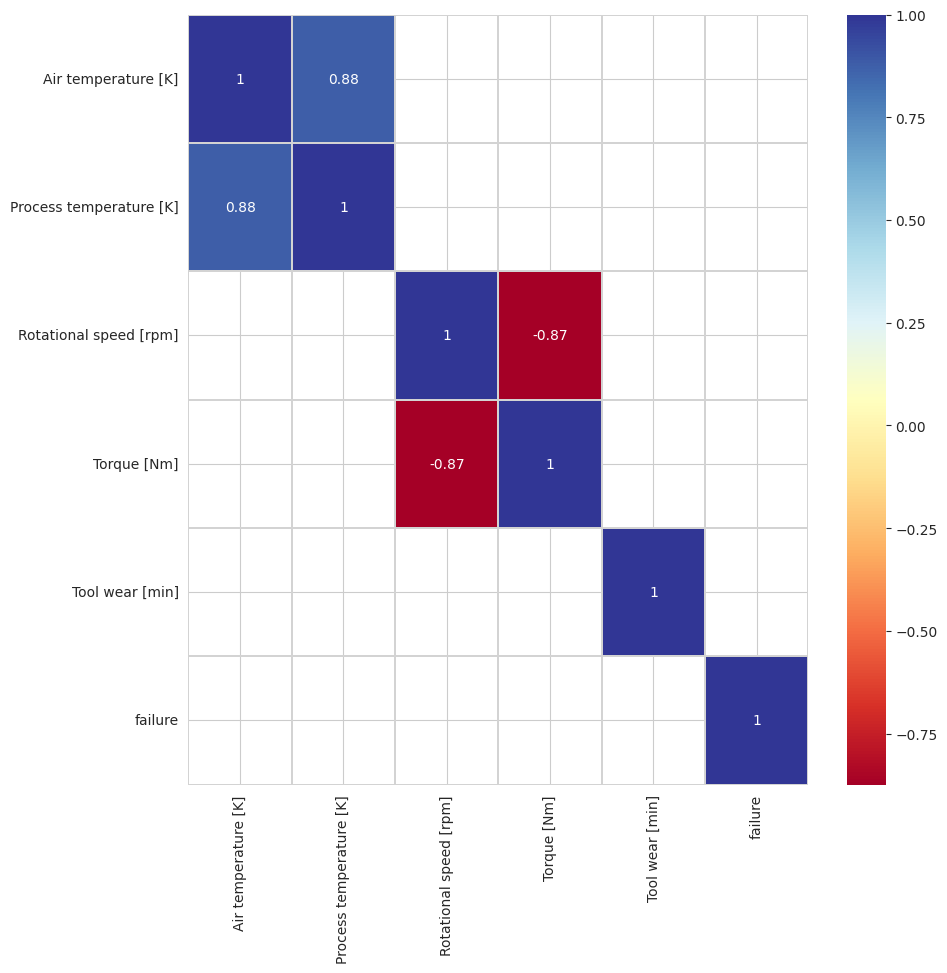

In [45]:
plt.figure(figsize=(10,10))
threshold = 0.80
sns.set_style("whitegrid", {"axes.facecolor": ".0"})
df_cluster2 = df_numeric.corr()
mask = df_cluster2.where((abs(df_cluster2) >= threshold)).isna()
plot_kws={"s": 1}
sns.heatmap(df_cluster2,
            cmap='RdYlBu',
            annot=True,
            mask=mask,
            linewidths=0.2,
            linecolor='lightgrey').set_facecolor('white')

In [46]:
df.drop(['Product ID'],axis=1,inplace=True)

In [47]:
list(df)

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'failure']

In [48]:
df = pd.get_dummies(df,drop_first=True)

In [49]:
features = list(df.columns)

In [50]:
for feature in features:
    print(feature + " - " + str(len(df[df[feature].isna()])))

Air temperature [K] - 0
Process temperature [K] - 0
Rotational speed [rpm] - 0
Torque [Nm] - 0
Tool wear [min] - 0
failure - 0


In [51]:
df_group = df.groupby(['failure'])
df_group.count()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
failure,,,,,
0.0,7729,7729,7729,7729,7729
1.0,271,271,271,271,271


In [52]:
df[df['failure'].isna()]

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],failure


In [53]:
df_numeric.fillna(df_numeric.mean(),inplace=True)

for feature in features:
    try:
        df[feature].fillna(df[feature].mean(),inplace=True)
    except:
        try:
            df[feature].fillna(df[feature].mode(),inplace=True)
        except:
            pass

/tmp/ipython-input-53-1318130641.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [54]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],8000.0,300.005450,1.996844,295.3,298.3,300.1,301.5,304.5
Process temperature [K],8000.0,310.006062,1.479432,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],8000.0,1539.356875,180.982943,1168.0,1422.0,1503.0,1613.0,2886.0
Torque [Nm],8000.0,40.003363,10.019546,3.8,33.2,40.1,46.8,76.6
Tool wear [min],8000.0,107.685000,63.612002,0.0,53.0,107.0,163.0,253.0
failure,8000.0,0.033875,0.180919,0.0,0.0,0.0,0.0,1.0


In [55]:
# Feature Selection
from sklearn.feature_selection import SelectKBest, chi2

best_features = SelectKBest(score_func=chi2,k='all')

X = df.iloc[:,:-1]
y = df.iloc[:,-1]
fit = best_features.fit(X,y)

df_scores=pd.DataFrame(fit.scores_)
df_col=pd.DataFrame(X.columns)

feature_score=pd.concat([df_col,df_scores],axis=1)
feature_score.columns=['feature','score']
feature_score.sort_values(by=['score'],ascending=True,inplace=True)

fig = go.Figure(go.Bar(
            x=feature_score['score'][0:21],
            y=feature_score['feature'][0:21],
            orientation='h'))

fig.update_layout(title="Top 20 Features",
                  height=1200,
                  showlegend=False,
                 )

fig.show()

In [56]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [57]:
X.head()
feature_names = list(X.columns)
np.shape(X)

(8000, 5)

In [58]:
np.shape(X)

(8000, 5)

In [59]:
df1 = pd.read_csv('test.csv')

In [60]:
X1 = df1.iloc[:,:-1]
y1 = df1.iloc[:,-1]

In [61]:
X1.drop(['Product ID'],axis=1,inplace=True)

In [62]:
from imblearn.over_sampling import SMOTE, SVMSMOTE,RandomOverSampler
oversamp = RandomOverSampler(random_state=0)

In [63]:
X,y = oversamp.fit_resample(X, y)


In [64]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X = sc.fit_transform(X)
X1 = sc.transform(X1)

In [66]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score,roc_auc_score, confusion_matrix,matthews_corrcoef
from sklearn.metrics import ConfusionMatrixDisplay # will plot the confusion matrix

import time
model_performance = pd.DataFrame(columns=['Accuracy','Recall','Precision','F1-Score','MCC score','time to train','time to predict','total time'])

In [89]:
%%time
from sklearn.linear_model import LogisticRegression
start = time.time()
model = LogisticRegression().fit(X,y)
end_train = time.time()
y_predictions = model.predict(X1) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 30.9 ms, sys: 0 ns, total: 30.9 ms
Wall time: 18.7 ms


In [90]:
accuracy = accuracy_score(y1, y_predictions)
recall = recall_score(y1, y_predictions, average='weighted')
precision = precision_score(y1, y_predictions, average='weighted')
f1s = f1_score(y1, y_predictions, average='weighted')
MCC = matthews_corrcoef(y1, y_predictions)
# ROC_AUC = roc_auc_score(y_test, y_predictions, average='weighted')
ROC_AUC = roc_auc_score(y1, model.predict_proba(X1)[:,1], average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("MCC: "+ "{:.2%}".format(MCC))
print("ROC AUC score: "+ "{:.2%}".format(ROC_AUC))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Logistic'] = [accuracy, recall, precision, f1s,MCC,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 81.40%
Recall: 81.40%
Precision: 96.39%
F1-Score: 87.17%
MCC: 29.03%
ROC AUC score: 90.83%
time to train: 0.02 s
time to predict: 0.00 s
total: 0.02 s


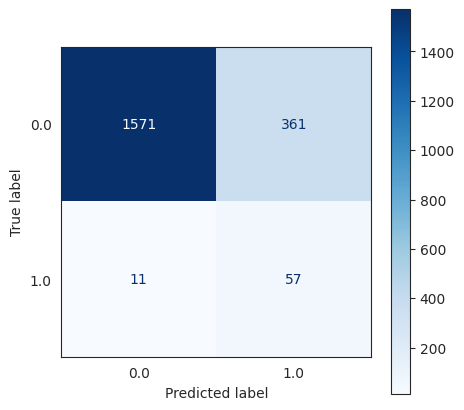

In [91]:
# Your existing settings
plt.rcParams['figure.figsize'] = 5, 5
sns.set_style("white")

# Updated code - replace the old plot_confusion_matrix line with this:
y_pred = model.predict(X1)  # Get predictions
cm = confusion_matrix(y1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [92]:
%%time
from sklearn.tree import DecisionTreeClassifier
start = time.time()
model = DecisionTreeClassifier().fit(X,y)
end_train = time.time()
y_predictions = model.predict(X1) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 27.1 ms, sys: 8 µs, total: 27.1 ms
Wall time: 26.9 ms


In [93]:
accuracy = accuracy_score(y1, y_predictions)
recall = recall_score(y1, y_predictions, average='weighted')
precision = precision_score(y1, y_predictions, average='weighted')
f1s = f1_score(y1, y_predictions, average='weighted')
MCC = matthews_corrcoef(y1, y_predictions)
# ROC_AUC = roc_auc_score(y_test, y_predictions, average='weighted')
ROC_AUC = roc_auc_score(y1, model.predict_proba(X1)[:,1], average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("MCC: "+ "{:.2%}".format(MCC))
print("ROC AUC score: "+ "{:.2%}".format(ROC_AUC))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Decision Tree Classifier'] = [accuracy, recall, precision, f1s,MCC,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 97.75%
Recall: 97.75%
Precision: 97.59%
F1-Score: 97.65%
MCC: 63.11%
ROC AUC score: 78.97%
time to train: 0.03 s
time to predict: 0.00 s
total: 0.03 s


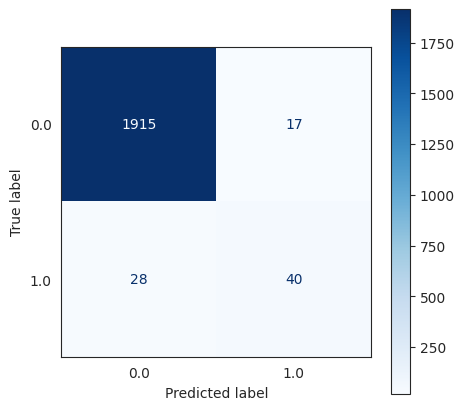

In [94]:
# Your existing settings
plt.rcParams['figure.figsize'] = 5, 5
sns.set_style("white")

# Updated code - replace the old plot_confusion_matrix line with this:
y_pred = model.predict(X1)  # Get predictions
cm = confusion_matrix(y1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [105]:
%%time
from sklearn.ensemble import RandomForestClassifier
start = time.time()
model2 = RandomForestClassifier(n_estimators = 100,n_jobs=-1,random_state=0,bootstrap=True,).fit(X,y)
end_train = time.time()
y_predictions = model.predict(X1) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 1.21 s, sys: 16.1 ms, total: 1.23 s
Wall time: 982 ms


In [96]:
accuracy = accuracy_score(y1, y_predictions)
recall = recall_score(y1, y_predictions, average='weighted')
precision = precision_score(y1, y_predictions, average='weighted')
f1s = f1_score(y1, y_predictions, average='weighted')
MCC = matthews_corrcoef(y1, y_predictions)
# ROC_AUC = roc_auc_score(y_test, y_predictions, average='weighted')
ROC_AUC = roc_auc_score(y1, model.predict_proba(X1)[:,1], average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("MCC: "+ "{:.2%}".format(MCC))
print("ROC AUC score: "+ "{:.2%}".format(ROC_AUC))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Random Forest Classifier'] = [accuracy, recall, precision, f1s,MCC,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 98.30%
Recall: 98.30%
Precision: 98.18%
F1-Score: 98.21%
MCC: 71.77%
ROC AUC score: 96.25%
time to train: 0.83 s
time to predict: 0.04 s
total: 0.88 s


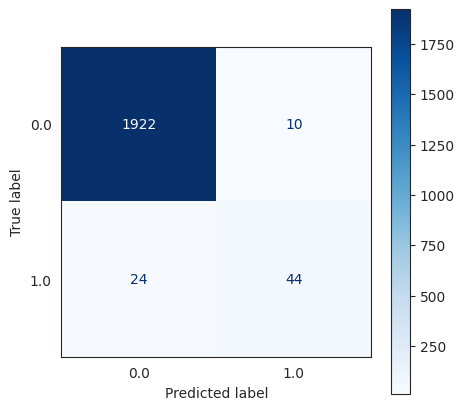

In [97]:
# Your existing settings
plt.rcParams['figure.figsize'] = 5, 5
sns.set_style("white")

# Updated code - replace the old plot_confusion_matrix line with this:
y_pred = model.predict(X1)  # Get predictions
cm = confusion_matrix(y1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [98]:
%%time
from sklearn.ensemble import GradientBoostingClassifier
start = time.time()
model = GradientBoostingClassifier().fit(X,y)
end_train = time.time()
y_predictions = model.predict(X1) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 1.31 s, sys: 4.16 ms, total: 1.32 s
Wall time: 1.31 s


In [99]:
accuracy = accuracy_score(y1, y_predictions)
recall = recall_score(y1, y_predictions, average='weighted')
precision = precision_score(y1, y_predictions, average='weighted')
f1s = f1_score(y1, y_predictions, average='weighted')
MCC = matthews_corrcoef(y1, y_predictions)
# ROC_AUC = roc_auc_score(y_test, y_predictions, average='weighted')
ROC_AUC = roc_auc_score(y1, model.predict_proba(X1)[:,1], average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("MCC: "+ "{:.2%}".format(MCC))
print("ROC AUC score: "+ "{:.2%}".format(ROC_AUC))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['Gradient Boosting Classifier'] = [accuracy, recall, precision, f1s,MCC,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 92.85%
Recall: 92.85%
Precision: 97.16%
F1-Score: 94.44%
MCC: 49.00%
ROC AUC score: 96.78%
time to train: 1.31 s
time to predict: 0.00 s
total: 1.31 s


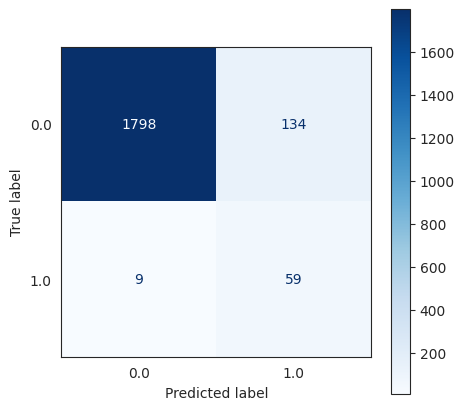

In [100]:
# Your existing settings
plt.rcParams['figure.figsize'] = 5, 5
sns.set_style("white")

# Updated code - replace the old plot_confusion_matrix line with this:
y_pred = model.predict(X1)  # Get predictions
cm = confusion_matrix(y1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [101]:
%%time
from sklearn.neural_network import MLPClassifier
start = time.time()
model = MLPClassifier(hidden_layer_sizes = (100,100,),
                      activation='relu',
                      solver='adam',
                      batch_size=2000,
                      verbose=0).fit(X,y)
end_train = time.time()
y_predictions = model.predict(X1) # These are the predictions from the test data.
end_predict = time.time()

CPU times: user 24.6 s, sys: 26.9 ms, total: 24.6 s
Wall time: 13.2 s


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



In [102]:
accuracy = accuracy_score(y1, y_predictions)
recall = recall_score(y1, y_predictions, average='weighted')
precision = precision_score(y1, y_predictions, average='weighted')
f1s = f1_score(y1, y_predictions, average='weighted')
MCC = matthews_corrcoef(y1, y_predictions)
# ROC_AUC = roc_auc_score(y_test, y_predictions, average='weighted')
ROC_AUC = roc_auc_score(y1, model.predict_proba(X1)[:,1], average='weighted')

print("Accuracy: "+ "{:.2%}".format(accuracy))
print("Recall: "+ "{:.2%}".format(recall))
print("Precision: "+ "{:.2%}".format(precision))
print("F1-Score: "+ "{:.2%}".format(f1s))
print("MCC: "+ "{:.2%}".format(MCC))
print("ROC AUC score: "+ "{:.2%}".format(ROC_AUC))
print("time to train: "+ "{:.2f}".format(end_train-start)+" s")
print("time to predict: "+"{:.2f}".format(end_predict-end_train)+" s")
print("total: "+"{:.2f}".format(end_predict-start)+" s")
model_performance.loc['MLP Classifier'] = [accuracy, recall, precision, f1s,MCC,end_train-start,end_predict-end_train,end_predict-start]

Accuracy: 91.30%
Recall: 91.30%
Precision: 97.13%
F1-Score: 93.46%
MCC: 46.22%
ROC AUC score: 95.48%
time to train: 13.20 s
time to predict: 0.00 s
total: 13.21 s


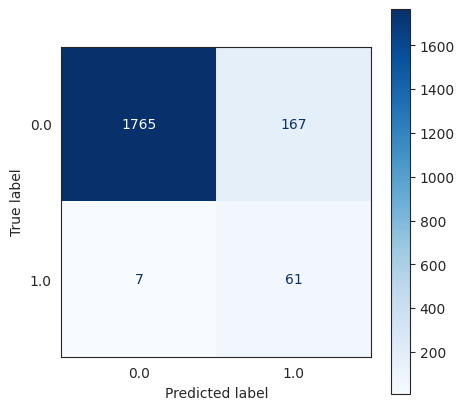

In [103]:
# Your existing settings
plt.rcParams['figure.figsize'] = 5, 5
sns.set_style("white")

# Updated code - replace the old plot_confusion_matrix line with this:
y_pred = model.predict(X1)  # Get predictions
cm = confusion_matrix(y1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [104]:
model_performance.fillna(.90,inplace=True)
model_performance.style.background_gradient(cmap='coolwarm').format({'Accuracy': '{:.2%}',
                                                                     'Precision': '{:.2%}',
                                                                     'Recall': '{:.2%}',
                                                                     'F1-Score': '{:.2%}',
                                                                     'MCC score': '{:.2%}',
                                                                     'time to train':'{:.1f}',
                                                                     'time to predict':'{:.1f}',
                                                                     'total time':'{:.1f}',
                                                                     })

,Accuracy,Recall,Precision,F1-Score,MCC score,time to train,time to predict,total time
Logistic,81.40%,81.40%,96.39%,87.17%,29.03%,0.0,0.0,0.0
Decision Tree Classifier,97.75%,97.75%,97.59%,97.65%,63.11%,0.0,0.0,0.0
Random Forest Classifier,98.30%,98.30%,98.18%,98.21%,71.77%,0.8,0.0,0.9
Gradient Boosting Classifier,92.85%,92.85%,97.16%,94.44%,49.00%,1.3,0.0,1.3
MLP Classifier,91.30%,91.30%,97.13%,93.46%,46.22%,13.2,0.0,13.2


In [107]:
import joblib
joblib.dump(model2, 'model.joblib')

['model.joblib']